# Lista 6 - K-médias e PCA

## Questão 1

Considere o conjunto de dados disponível em **quake.csv**, organizado em 2 colunas de atributos. Os dados referem-se a latitudes e longitudes de locais em que foram registrados terremotos.

a) Avalie o algoritmo K-médias com distância Euclidiana na tarefa de agrupamento para tais dados. O número de grupos deve ser escolhido entre os valores 4, 5, 6, ..., 19, 20 a partir do índice DB (Davies-Bouldin). Plote o melhor resultado de agrupamento obtido.

**Observação:** Em cada avaliação repita múltiplas vezes (por exemplo, 20) a execução do algoritmo K-médias, escolhendo a solução com melhor erro de reconstrução.

In [1]:
import sys
sys.path.append("../")

### **Solução**

In [3]:
# 1. Importação das bibliotecas necessárias
import numpy as np
import matplotlib.pyplot as plt
from utils.utils import quake, davies_bouldin
from preprocessors.normalizador import Normalizador
from models.kmedias import Kmedias

In [4]:
# 2. Coleta dos dados
X = quake.copy()

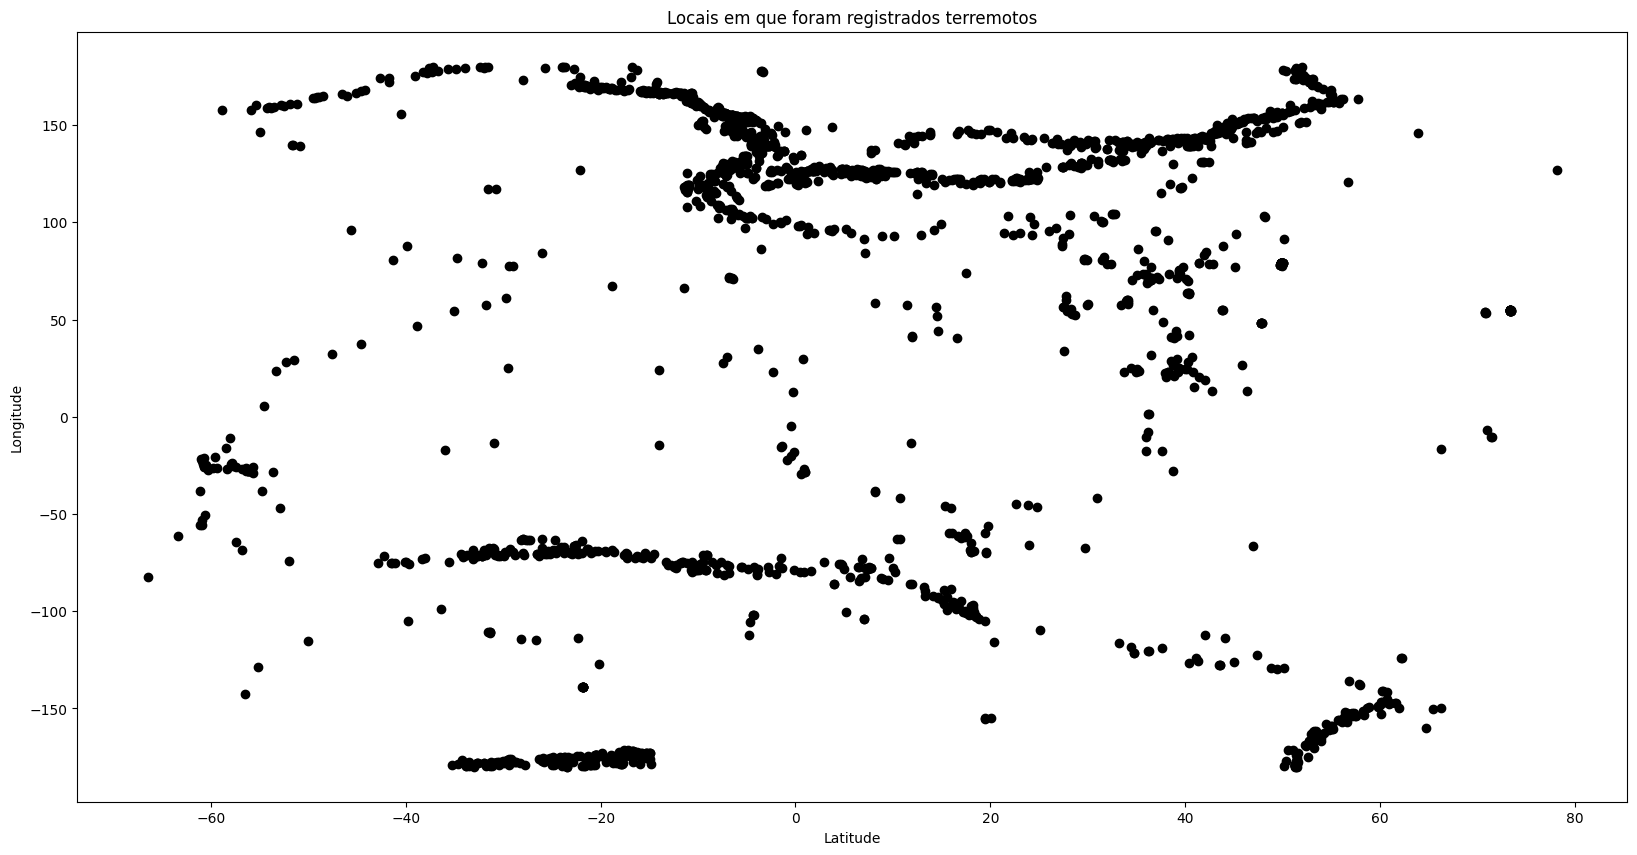

In [5]:
# 3. Visualização simples do problema antes de realizar a tarefa de agrupamento
plt.figure(figsize=(20,10))
plt.scatter(X[:, 0], X[:, 1], c="black")
plt.title("Locais em que foram registrados terremotos")
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.show()

In [4]:
# 4. Normalização dos dados
normalizador_min_max = Normalizador(X)
X_normalizado = normalizador_min_max.normaliza(X)

In [ ]:
# 5. Avaliação do algoritmo K-médias para diferentes valores de K
# Quantidade de grupos a avaliar
K = np.arange(4, 21)

# Valores referentes ao índice DB de cada clustering
DB_index = []

# Valores referentes ao erro de reconstrução de cada clustering
erro = []

# Modelos cujos valores de K foram melhores nas múltiplas execuções
modelos = []

# Execução múltipla (n_trials vezes) de cada candidato à K
#n_trials = 20
n_trials = 1
for k in K:
    DB_index_k = 0
    erro_min_k = 10000000000000000000
    for i in range(n_trials):
        modelo_Kmedias = Kmedias(k, ini="k-means++")
        modelo_Kmedias.ajuste(X_normalizado)
        erro_k = modelo_Kmedias.erro_de_reconstrucao
        if erro_k < erro_min_k:
            erro_min_k = erro_k
            DB_index_k = davies_bouldin(modelo_Kmedias.clusters)
            modelo_k = modelo_Kmedias
    erro.append(erro_min_k)
    DB_index.append(DB_index_k)
    modelos.append(modelo_k)

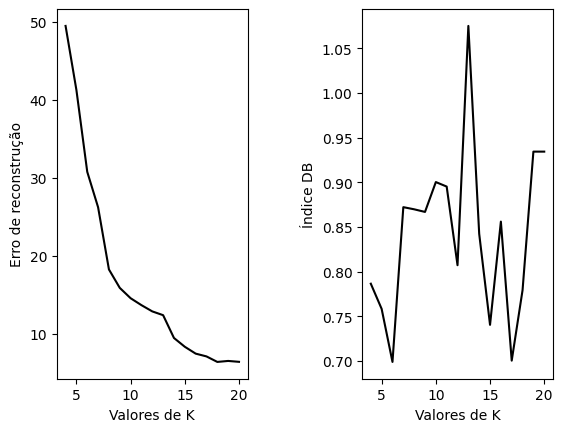

In [6]:
# 6. Avaliação dos diferentes erros de reconstrução/Índice Davies-Bouldin para cada valor de k
# plot do erro de reconstrução
plt.subplot(1,2,1)
x = K
y = np.array(erro)
plt.ylabel("Erro de reconstrução")
plt.xlabel("Valores de K")
plt.plot(x, y, color="black")

# plot do Índice DB 
plt.subplot(1,2,2)
x = K
y = np.array(DB_index)
plt.ylabel("Índice DB")
plt.xlabel("Valores de K")
plt.plot(x, y, color="black")
plt.subplots_adjust(wspace=0.6)
plt.show()

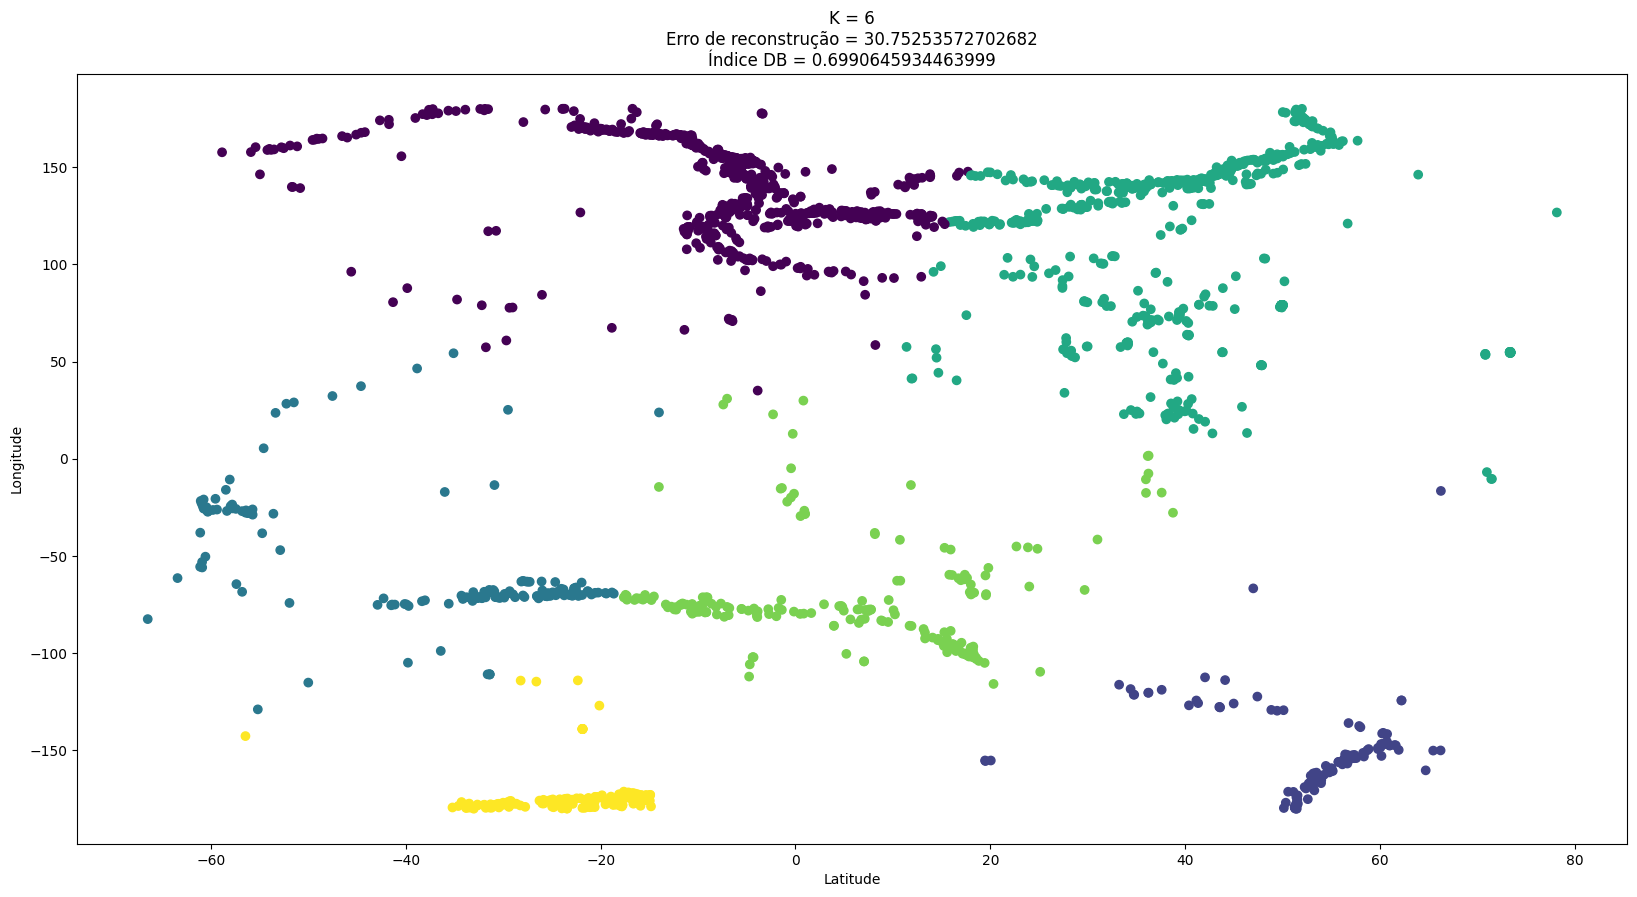

In [18]:
# 7. Plot do melhor agrupamento obtido pela execução múltipla de cada valor de k
plt.figure(figsize=(20,10))
plt.scatter(X[:, 0], X[:, 1], c=modelos[2].c)
plt.title(f"K = {K[2]}\nErro de reconstrução = {erro[2]}\nÍndice DB = {DB_index[2]}")
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.show()

###
b) Repita o item anterior considerando a distância de Mahalanobis.

### **Solução**

In [ ]:
# 5. Avaliação do algoritmo K-médias para diferentes valores de K
# Quantidade de grupos a avaliar
K = np.arange(4, 21)

# Valores referentes ao índice DB de cada clustering
DB_index_mahalanobis = []

# Valores referentes ao erro de reconstrução de cada clustering
erro_mahalanobis = []

# Modelos cujos valores de K foram melhores nas múltiplas execuções
modelos_mahalanobis = []

# Execução múltipla (20 vezes) de cada candidato à K
#n_trials = 20
n_trials = 1
for k in K:
    DB_index_k = 0
    erro_min_k = 10000000000000000000
    for i in range(n_trials):
        modelo_Kmedias = Kmedias(k, ini="k-means++", funcao_de_dissimilaridade="mahalanobis")
        modelo_Kmedias.ajuste(X_normalizado)
        erro_k = modelo_Kmedias.erro_de_reconstrucao
        if erro_k < erro_min_k:
            erro_min_k = erro_k
            DB_index_k = davies_bouldin(modelo_Kmedias.clusters)
            modelo_k = modelo_Kmedias
    erro_mahalanobis.append(erro_min_k)
    DB_index_mahalanobis.append(DB_index_k)
    modelos_mahalanobis.append(modelo_k)

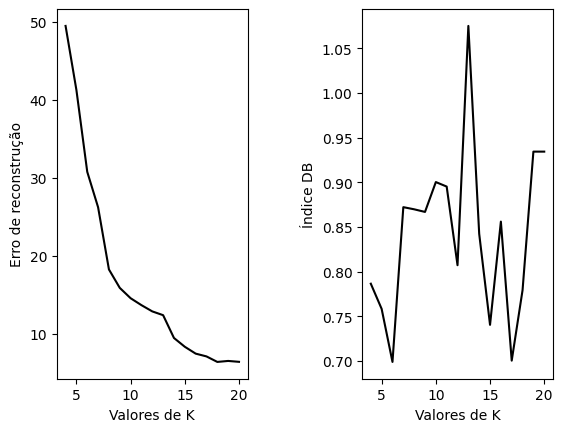

In [ ]:
# 6. Avaliação dos diferentes erros de reconstrução/Índice Davies-Bouldin para cada valor de k
# plot do erro de reconstrução
plt.subplot(1,2,1)
x = K
y = np.array(erro_mahalanobis)
plt.ylabel("Erro de reconstrução")
plt.xlabel("Valores de K")
plt.plot(x, y, color="black")

# plot do Índice DB 
plt.subplot(1,2,2)
x = K
y = np.array(DB_index_mahalanobis)
plt.ylabel("Índice DB")
plt.xlabel("Valores de K")
plt.plot(x, y, color="black")
plt.subplots_adjust(wspace=0.6)
plt.show()

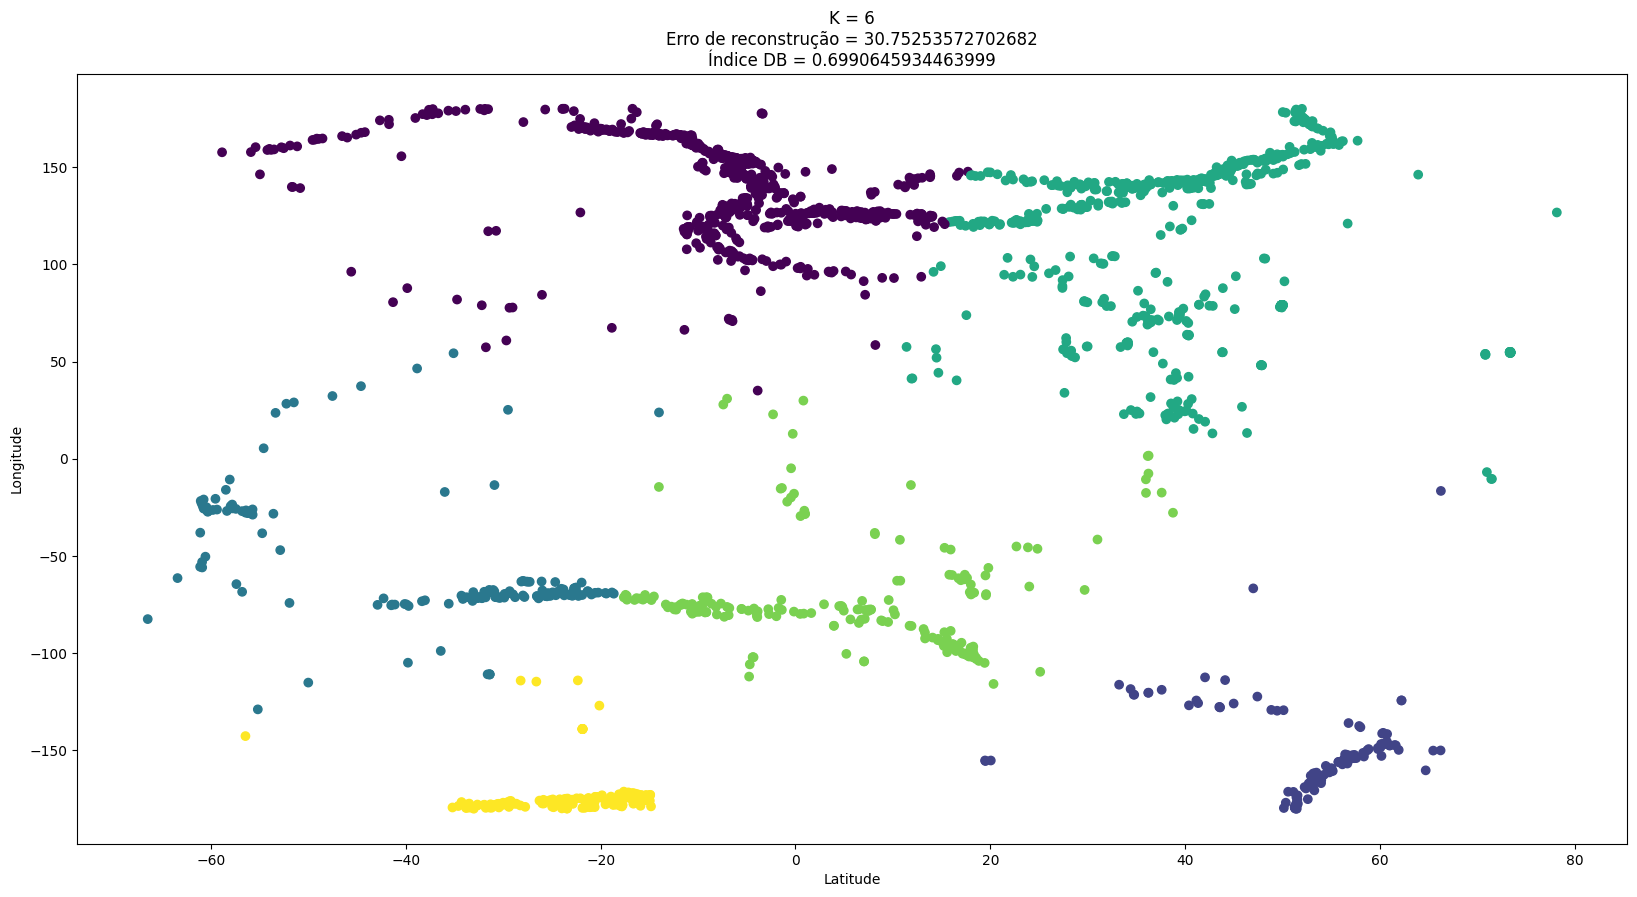

In [ ]:
# 7. Plot do melhor agrupamento obtido pela execução múltipla de cada valor de k
idx = DB_index.index(min(DB_index))
plt.figure(figsize=(20,10))
plt.scatter(X[:, 0], X[:, 1], c=modelos[2].c)
plt.title(f"K = {K[idx]} (mahalanobis)\nErro de reconstrução = {erro_mahalanobis[idx]}\nÍndice DB = {DB_index_mahalanobis[idx]}")
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.show()

## Questão 2

Considere o conjunto de dados disponível em **penguins.csv**, organizado em 5 colunas, sendo 4 colunas de atributos e a última a classe do padrão. Os dados referem-se a medições anatômicas de pinguins da Antártida, classificados nas espécies Adelie, Chinstrap e Gentoo.

a) Apresente a projeção em 2 dimensões dos padrões acima obtida pelo método PCA (análise dos componentes principais).

### **Solução**

In [6]:
# 1. Importação das bibliotecas necessárias
import numpy as np
import matplotlib.pyplot as plt
from utils.utils import penguins
from preprocessors.normalizador import Normalizador
from models.analise_de_componentes_principais import PCA

In [2]:
# 2. Coleta dos dados
X = penguins[:, 0:-1]
y = penguins[:, [-1]]

In [3]:
# 3. Normalização dos dados de entrada
normalizador = Normalizador(X)
X_normalizado = normalizador.normaliza(X)

In [4]:
# 4. Projeção dos padrões em 2 componentes (dimensões)
metodo_PCA = PCA(n_de_componentes=2)
metodo_PCA.ajuste(X_normalizado)
Z = metodo_PCA.prever(X_normalizado)
Z

array([[-0.05639572, -0.75623619],
       [-0.1886609 , -0.64685898],
       [-0.17823148, -0.70737108],
       [-0.07102629, -0.77587405],
       [-0.03824389, -0.95821974],
       [-0.08153891, -0.65687294],
       [-0.29552531, -0.92170206],
       [-0.06807111, -0.65701165],
       [-0.0305044 , -1.01429005],
       [-0.14408619, -0.97458418],
       [-0.10277048, -0.62512448],
       [-0.13462592, -0.78708771],
       [-0.27766227, -1.08600892],
       [ 0.02553341, -0.6213761 ],
       [-0.20755948, -1.20880153],
       [ 0.06584295, -0.66119556],
       [-0.00424072, -0.72026928],
       [-0.07688556, -0.76284339],
       [-0.14685579, -0.6980681 ],
       [-0.12749047, -0.60340138],
       [-0.06361125, -0.71847274],
       [-0.07251947, -0.7671008 ],
       [-0.09593956, -0.68432934],
       [ 0.1385414 , -0.67566797],
       [-0.08505071, -0.81110302],
       [-0.05920913, -0.533874  ],
       [-0.05329455, -0.664301  ],
       [-0.11292249, -0.66296875],
       [-0.1242888 ,

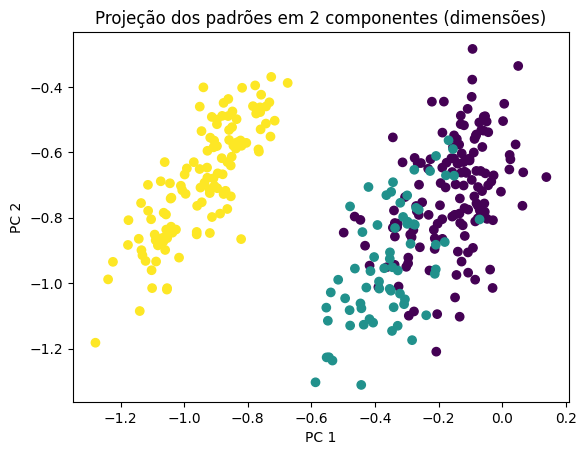

In [5]:
# 5. Exibição dos padrões projetados
plt.scatter(Z[:, 0], Z[:, 1], c=y)
plt.title("Projeção dos padrões em 2 componentes (dimensões)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()

###
b) Ainda considerando o item anterior, calcule e mostre a variância explicada obtida quando a dimensão projetada é modificada (1, 2, 3 ou 4).

### **Solução**

In [6]:
# 6. Cálculo das variâncias explicadas através da inicialização de diferentes métodos PCAs
variancias_explicadas = np.array([])
for pc in range(1, 5):
    pca = PCA(n_de_componentes=pc)
    pca.ajuste(X_normalizado)
    variancias_explicadas = np.append(variancias_explicadas, pca.variancia_explicada)

In [7]:
print("======================= Variância explicada =======================")
for pc in range(4):
    print(f"Variância explicada (Número de dimensões = {pc+1}): {variancias_explicadas[pc]}")


======================= Variância explicada =======================
Variância explicada (Número de dimensões = 1): 0.13991555145892084
Variância explicada (Número de dimensões = 2): 0.17842709752107094
Variância explicada (Número de dimensões = 3): 0.19515868248322482
Variância explicada (Número de dimensões = 4): 0.20092558216954584


In [8]:
# 7. Cálculo das proporções das variâncias explicadas
proporcao_de_variancia_explicada = np.array([])
pca_4 = PCA(n_de_componentes=4)
pca_4.ajuste(X_normalizado)

variancias_explicadas_relativas = pca_4.variancias_projetadas / pca_4.variancias_projetadas.sum()
for i, p in enumerate(variancias_explicadas_relativas):
    proporcao_de_variancia_explicada = np.append(proporcao_de_variancia_explicada, variancias_explicadas_relativas[:i+1].sum())

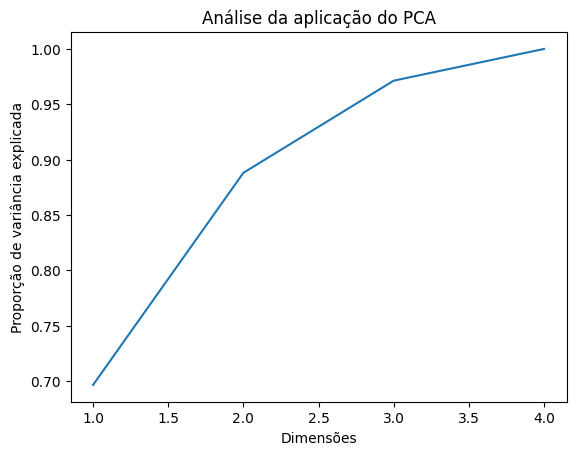

In [9]:
# 7. Exibição da taxa de proporção das variâncias explicadas conforme aumento do número de dimensões
D = np.arange(1, 5)

plt.plot(D, proporcao_de_variancia_explicada)
plt.title("Análise da aplicação do PCA")
plt.xlabel("Dimensões")
plt.ylabel("Proporção de variância explicada")
plt.show()